In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys

import Bio.SeqUtils
import Bio.Data

from Bio import SeqIO
from Bio.Seq import Seq
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

# load all utils functions
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "utils_files"))
from model_utils import *
from data_utils import *
from dataloader import MtbGeneDataset
from inSilicoMut_utils import *

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression

results_path = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
vcf_dir = "/n/scratch3/users/s/sak0914/annotated_VCF"

who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
# df_mxf = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/MXF/data_for_model.csv")
df_rif = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/data_for_model.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/mycobrowser_h37rv_genes_v4.csv")

2023-02-11 11:41:46.839296: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-02-11 11:41:47.296257: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-02-11 11:41:47.296297: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-02-11 11:41:50.769869: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

# Uncertain Significance Sites (in WHO Catalog) Investigation

## Focus on rpoB first, then move on to other genes

In [2]:
rif_rpoBC_df = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")

for i, row in rif_rpoBC_df.iterrows():
    if ".0" in row["Pos"]:
        rif_rpoBC_df.loc[i, "Pos"] = int(row["Pos"].replace(".0", ""))
        
        
# get dictionaries mapping WHO categories to unique sites and dataframes
rpoB_sites_dict, rpoB_dfs_dict = get_dict_WHO_mutations_sites(who_variants, "RIF", "rpoB")

In [3]:
# all rpoB mutations merged with the saliency dataframe
rpoB_ALL = pd.concat([rpoB_dfs_dict[num] for num in range(1, 6)], axis=0)
rpoB_ALL = rif_rpoBC_df.merge(rpoB_ALL, left_on="Pos", right_on="genome_index", how="inner").reset_index(drop=True)

# all uncertain rpoB mutations in the WHO catalog. Merge with saliency dataframe to see scores with mutations
# it will be a little smaller than the full WHO list of rpoB category 3 mutations because we limited the 5' end of the alignment more than WHO
rpoB_ALL_cat3 = rpoB_ALL.query("confidence.str.contains('3')").reset_index(drop=True)

# get only those with significant saliency scores
rpoB_significant_cat3 = rpoB_ALL_cat3.query("Max_Sig==1 | Min_Sig==1")
print(f"{len(rpoB_significant_cat3.mutation.unique())} significant category 3 rpoB mutations across {len(rpoB_significant_cat3['genome_index'].unique())} sites")

rpoB_significant_cat3 = get_data_for_synthetic_VCF(rpoB_significant_cat3, "pos")

if len(rpoB_significant_cat3.loc[(pd.isnull(rpoB_significant_cat3["REF"])) | pd.isnull(rpoB_significant_cat3["ALT"])]) > 0:
    print("There are NaNs in the REF or ALT columns!")

243 significant category 3 rpoB mutations across 199 sites


In [4]:
len(rpoB_ALL_cat3), len(rpoB_ALL_cat3.mutation.unique()), len(rpoB_ALL_cat3.genome_index.unique())

(602, 598, 541)

In [5]:
# fig, ax = plt.subplots()
# sns.histplot(np.log(rpoB_ALL_cat3.drop_duplicates("Pos", keep="first").query("Max_Sig==1")["Max"]), ax=ax)

# new_tick_labels = ["{:.0e}".format(val) if val < 0.01 else np.round(val , 2) for val in np.exp(ax.get_xticks())]
# plt.title("Significant Positive Saliency Scores in Uncertain rpoB Sites")
# ax.set_xticks(ticks=ax.get_xticks(), labels=new_tick_labels)
# sns.despine()
# plt.show()

In [6]:
# fig, ax = plt.subplots()
# sns.histplot(np.log(-rpoB_ALL_cat3.drop_duplicates("Pos", keep="first").query("Min_Sig==1")["Min"]), ax=ax)

# new_tick_labels = ["{:.0e}".format(-val) if val < 0.01 else np.round(-val , 2) for val in np.exp(ax.get_xticks())]
# plt.title("Significant Negative Saliency Scores in Uncertain rpoB Sites")
# ax.set_xticks(ticks=ax.get_xticks(), labels=new_tick_labels)
# sns.despine()
# plt.show()

# Write Variants to Synthetic VCF Files and Save a txt file of them

## Both of these components are needed to run <code>04_make_MSA.py</code>

In [ ]:
"/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/insilico_analysis/highConf_mutation_names.txt"

In [22]:
def create_synthetic_VCF_files(df, out_fName, vcf_dir="/n/scratch3/users/s/sak0914/annotated_VCF"):

    # create a header section
    header = '##fileformat=VCFv4.1\n'
    header += "##contig=<ID=NC_000962.3,length=4411532>\n"
    header += '#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\tFORMAT\tSample\n'

    # text file for the list of mutation files (isolate name only) to pass into SNP concatenator later
    with open(out_fName, "w+") as out_file:

        # ITERATE through each mutation. N_mutations = N_files to be created. 
        # There can be multiple single site variants to make for a given mutation
        for mutation in df["mutation"].unique():
            
            # write the mutation name to the out text file    
            out_file.write(f'{mutation}\n')

            variants_to_add = []

            # iterate through each single variant for a given mutation
            for i, row in df.query("mutation==@mutation").reset_index(drop=True).iterrows():
                
                variants_to_add.append(['NC_000962.3', row["POS"], '.', row["REF"], row["ALT"], '.', 'PASS', '.', 'GT', '1/1'])

                # create a VCF file for the mutation
                with open(f'{vcf_dir}/{mutation}.vcf', 'w+') as vcf_file:

                    # write VCF file header
                    vcf_file.write(header)

                    # iterate through all the variants and add them
                    for variant in variants_to_add:
                        vcf_file.write('\t'.join(str(x) for x in variant) + '\n')

In [ ]:
def get_data_for_synthetic_VCF(df, sense):
    
    aa_to_codon_table = get_aa_to_codon_table()
    
    if "genome_index" in df.columns and "POS" not in df.columns:
        df.rename(columns={"genome_index": "POS"}, inplace=True)
        
    df[["gene", "variant"]] = df["mutation"].str.split("_", expand=True, n=1)
    
    if sense.upper() == "POS":
        
        for i, row in df.iterrows():

            # reference nucleotide at the site
            ref = h37Rv.seq[row["POS"] - 1]
            df.loc[i, "REF"] = ref

            if "p." not in row["variant"]:
                if ">" in row["variant"]:
                    df.loc[i, "ALT"] = row["variant"].split(">")[1]
                elif "ins" in row["variant"]:
                    df.loc[i, "ALT"] = ref + row["variant"].split("ins")[1]
                elif "del" in row["variant"]:
                    df.loc[i, "ALT"] = row["variant"].split("ins")[1].replace(ref, "")
            else:
                clean_var = row["variant"].replace("p.", "")

                # separate the mutation before, after, and position
                # get the indices of the position (numeric characters), then everything before or after is the mutation
                num_idx = []
                for k, char in enumerate(clean_var):
                    if char.isdigit():
                        num_idx.append(k)

                aa1 = clean_var[:num_idx[0]]
                aa2 = clean_var[num_idx[-1]+1:]

                if aa1 in Bio.SeqUtils.IUPACData.protein_letters_3to1.keys():

                    aa_pos = int(clean_var[num_idx[0]:num_idx[-1]+1])

                    start, end = h37Rv_genes.query(f"Symbol=='{row['gene']}'")[["Start", "End"]].values[0]
                    codon, codon_pos = get_codon_from_seq(h37Rv.seq, aa_pos, start, end)

                    # double checking methods. Check that the codon retrieved from the reference sequence is the same as the variant
                    assert Bio.SeqUtils.IUPACData.protein_letters_1to3[codon.translate()] == aa1

                    if aa2 in Bio.SeqUtils.IUPACData.protein_letters_3to1.keys():

                        # list of possible codons
                        possible_new_codons = aa_to_codon_table.query("AA==@aa2").Codon.values

                        # the index to replace. This looks for genome_index within the 3 positions of the codon values
                        idx_to_replace = codon_pos.index(row["POS"])

                        assert row["POS"] in codon_pos
                        df.loc[i, "ALT"] = np.random.choice(possible_new_codons)[idx_to_replace]

                    # insertion or deletion
                    else:
                        if "dup" in clean_var:
                            # get position, then randomly add one of the possible codons
                            df.loc[i, "ALT"] = ref + np.random.choice(possible_new_codons)

                #else:
                    # TODO: NEED AN EXAMPLE FIRST THO TO HELP FIGURE THIS ONE OUT
                    
    #else:
        # TODO: ALSO NEED AN EXAMPLE FOR NEGATIVE SENSE CASE BEFORE WRITING
        
    return df

In [47]:
def is_list_consecutive(l):
    return sorted(l) == list(range(min(l), max(l)+1))

In [54]:
variant = "p.Thr427_Gln429delinsLys"
clean_var = variant.replace("p.", "")

# separate the mutation before, after, and position
# get the indices of the position (numeric characters), then everything before or after is the mutation
num_idx = []
for k, char in enumerate(clean_var):
    if char.isdigit():
        num_idx.append(k)

if is_list_consecutive(num_idx):
    assert len(num_idx) == 3
    aa1 = clean_var[:num_idx[0]]
    aa2 = clean_var[num_idx[-1]+1:]
else:


Thr427_Gln429delinsLys [3, 4, 5, 10, 11, 12]


In [212]:
ref = h37Rv.seq[761085 - 1]
ref

'A'

In [236]:
def get_data_for_synthetic_VCF(df, sense):
    
    aa_to_codon_table = get_aa_to_codon_table()
    
    if "genome_index" in df.columns and "POS" not in df.columns:
        df.rename(columns={"genome_index": "POS"}, inplace=True)
        
    df[["gene", "variant"]] = df["mutation"].str.split("_", expand=True, n=1)
    
    if sense.upper() == "POS":
        
        for i, row in df.iterrows():

            # reference nucleotide at the site
            ref = h37Rv.seq[row["POS"] - 1]
            df.loc[i, "REF"] = ref

            try:
                if "p." not in row["variant"]:
                    if ">" in row["variant"]:
                        df.loc[i, "ALT"] = row["variant"].split(">")[1]
                    elif "ins" in row["variant"]:
                        df.loc[i, "ALT"] = ref + row["variant"].split("ins")[1]
                    elif "del" in row["variant"]:
                        df.loc[i, "ALT"] = row["variant"].split("ins")[1].replace(ref, "")
                else:
                    clean_var = row["variant"].replace("p.", "")

                    # separate the mutation before, after, and position
                    # get the indices of the position (numeric characters), then everything before or after is the mutation
                    num_idx = []
                    for k, char in enumerate(clean_var):
                        if char.isdigit():
                            num_idx.append(k)

                    aa1 = clean_var[:num_idx[0]]
                    aa2 = clean_var[num_idx[-1]+1:]

                    if aa1 in Bio.SeqUtils.IUPACData.protein_letters_3to1.keys():

                        aa_pos = int(clean_var[num_idx[0]:num_idx[-1]+1])

                        start, end = h37Rv_genes.query(f"Symbol=='{row['gene']}'")[["Start", "End"]].values[0]
                        codon, codon_pos = get_codon_from_seq(h37Rv.seq, aa_pos, start, end)

                        # double checking methods. Check that the codon retrieved from the reference sequence is the same as the variant
                        assert Bio.SeqUtils.IUPACData.protein_letters_1to3[codon.translate()] == aa1

                        if aa2 in Bio.SeqUtils.IUPACData.protein_letters_3to1.keys():

                            # list of possible codons
                            possible_new_codons = aa_to_codon_table.query("AA==@aa2").Codon.values

                            # the index to replace. This looks for genome_index within the 3 positions of the codon values
                            idx_to_replace = codon_pos.index(row["POS"])

                            assert row["POS"] in codon_pos
                            df.loc[i, "ALT"] = np.random.choice(possible_new_codons)[idx_to_replace]

                        # insertion or deletion
                        else:
                            if "dup" in clean_var:
                                # get position, then randomly add one of the possible codons
                                df.loc[i, "ALT"] = ref + np.random.choice(possible_new_codons)
            except:
                print(row["variant"], row["Pos"], ref)

                    #else:
                        # TODO: NEED AN EXAMPLE FIRST THO TO HELP FIGURE THIS ONE OUT
                    
        #else:
            # TODO: ALSO NEED AN EXAMPLE FOR NEGATIVE SENSE CASE BEFORE WRITING
        
    return df

In [237]:
_ = get_data_for_synthetic_VCF(rpoB_ALL.query("confidence.str.contains('|'.join(['1', '2'])) & (Max_Sig == 1)"), "pos")

p.Thr427_Gln429del 761083 G
p.Thr427_Leu430del 761084 C
p.Thr427_Gln429delinsLys 761085 A
p.Gln432_Met434del 761097 A
p.Ser431_Gln432insHis 761098 G
p.Gln432_Phe433del 761098 G
p.Phe433_Gln436del 761098 G
p.Gln432_Asp435delinsHis 761100 C
p.Met434_Asn437delinsIle 761106 A
p.Gln436_Asn437del 761109 G
p.Asp435_Gln436delinsGlu 761109 G
p.His445_Lys446del 761137 C


In [239]:
rpoB_ALL.query("confidence.str.contains('|'.join(['1', '2'])) & (Max_Sig == 1) & mutation=='rpoB_p.Thr427_Gln429del'")

,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,drug,genome_index,confidence,mutation
257,rpoBC,761083,0.017214,0.0,0.000002,1.0,0.0,1,0,RIF,761083,2) Assoc w R - Interim,rpoB_p.Thr427_Gln429del


In [245]:
who_variants.query("mutation in ['rpoB_p.Thr427_Gln429del', 'rpoB_p.Thr427_Leu430del', 'rpoB_p.Thr427_Gln429delinsLys']")

,drug,genome_index,confidence,mutation
431,RIF,761085,2) Assoc w R - Interim,rpoB_p.Thr427_Gln429delinsLys
446,RIF,761083,2) Assoc w R - Interim,rpoB_p.Thr427_Gln429del
447,RIF,761084,2) Assoc w R - Interim,rpoB_p.Thr427_Leu430del


In [225]:
def parse_complex_variants(clean_var, num_idx):
    
    if len(num_idx) == 6:
        print(clean_var, num_idx)
    else:
        print(f"There are more than 6 numerical characters in {clean_var}!")
    
    # need to remove all sites inclusive
    start_site = int(clean_var[num_idx[0]:num_idx[2]+1])
    end_site = int(clean_var[num_idx[3]:num_idx[-1]+1])
    
    start_codon, start_codon_sites = get_codon_from_seq(h37Rv.seq, start_site, start, end)
    end_codon, end_codon_sites = get_codon_from_seq(h37Rv.seq, end_site, start, end)
    
    # nucleotide coordinates to remove
    if "del" in clean_var:
        remove_nucleotides = np.min(start_codon_sites), np.max(end_codon_sites)
        
        if "ins" in clean_var:
            
        else:
            
    
    return remove_nucleotides

In [235]:
clean_var

'Thr427_Gln429delinsLys'

In [226]:
parse_complex_variants(clean_var, num_idx)

Thr427_Gln429delinsLys [3, 4, 5, 10, 11, 12]


(761085, 761093)

In [228]:
h37Rv.seq[761085-1:761093]

Seq('ACCAGCCAG')

In [208]:
parse_complex_variants(clean_var, num_idx)

Thr427_Gln429delinsLys [3, 4, 5, 10, 11, 12]


((Seq('ACC'), [761085, 761086, 761087]),
 (Seq('CAG'), [761091, 761092, 761093]))

In [ ]:
get_codon_from_seq

In [25]:
create_synthetic_VCF_files(, 
                           "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_highConf_mutations.txt", 
                           "/n/scratch3/users/s/sak0914/temp_VCF"
                          )

KeyError: 'POS'

# Predict MICs for Synthetic Sequences (single mutations inserted into H37Rv)

In [170]:
rif_rpoBC_df = pd.read_csv("Rifampicin/rpoBC_saliency_results.csv")
for i, row in rif_rpoBC_df.iterrows():
    if ".0" in row["Pos"]:
        rif_rpoBC_df.loc[i, "Pos"] = row["Pos"].replace(".0", "")
        
locus_list = ["rpoBC"]
df_genos = make_genotype_df(locus_list, "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis")
keep_strains = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoB_uncertain_mutations.txt", sep="\t", header=None)[0].values
df_genos = df_genos.loc[keep_strains]

# Apply one-hot encoding function to get each isolate sequence
print('making one hot encoding for...')
for locus in locus_list:
    print("...", locus)
    lengths = [len(seq) for seq in df_genos[locus]]
    assert len(np.unique(lengths)) == 1
    df_genos[locus + "_one_hot"] = df_genos[locus].apply(np.vectorize(get_one_hot))
    
X = create_X(df_genos)
print(X.shape)

1 loci!
reading fasta file /n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/RIF/inSilico_analysis/rpoBC.fasta
making one hot encoding for...
... rpoBC
found 1 genes and longest gene 7814
(243, 5, 7814, 1)


In [171]:
# load in saved best model (NO LINEAGES BECAUSE IT WASN'T SIGNIFICANT FOR RIFAMPICIN)
config_file = "../config_rif.yaml"
kwargs = yaml.safe_load(open(config_file, "r"))

drug = kwargs["drug"]
locus_list = kwargs["locus_list"]
filter_size = kwargs["filter_size"]
BATCH_SIZE = kwargs["batch_size"]
N_epochs = kwargs["N_epochs"]
patience_epochs = kwargs["patience_epochs"]

output_path = kwargs["output_path"]
phenotype_file = kwargs["phenotype_file"]
genotype_input_directory = kwargs["genotype_input_directory"]
binary_thresh = kwargs["binary_thresh"]
include_lineage = kwargs["include_lineage"]
loss_type = kwargs["loss_type"]
binary = False
bounded_loss = True

num_loci = len(locus_list)
df_phenos = pd.read_csv(phenotype_file)

# get longest locus from the pickle file
X_h37rv = sparse.load_npz(os.path.join(output_path, 'pkl_sparse_ref.npz'))

# shape = 1 x 5 x longest_locus x num_loci
longest_locus = X_h37rv.shape[2]
del X_h37rv

if include_lineage:
    num_lineages = train_generator[0][0][1].shape[1]
else:
    num_lineages = 0

best_model = conv_nn(binary, longest_locus, num_loci, num_lineages, bounded_loss, filter_size)
best_model.load_weights(os.path.join(output_path, "best_model.h5"))

2023-02-10 15:47:51.001644: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-02-10 15:47:51.001708: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2023-02-10 15:47:51.001738: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (compute-e-16-189.o2.rc.hms.harvard.edu): /proc/driver/nvidia/version does not exist
2023-02-10 15:47:51.002024: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Fitting quantitative model


In [172]:
# requires X, lower bounds, and upper bounds. For prediction, the bounds don't matter 
# they only matter for computing error, so just put in zeros

# X and df_genos are in the same order because df_genos is passed in as an argument to the function to make X
predicted_mics = best_model.predict([X, np.zeros(X.shape[0]), np.zeros(X.shape[0])]).flatten()

# add to the dataframe
df_genos["MIC_pred"] = predicted_mics

8/8 [==============================] - 5s 546ms/step


In [173]:
def combine_score_across_multiple_sites(multi_site_str):

    split_sites = multi_site_str.split(",")
    sig_score_sites = []

    for site in split_sites:

        if len(plot_df.query("genome_index==@site & Max_Sig == 1")) > 0:
            max_score = plot_df.query("genome_index==@site & Max_Sig == 1").Max.values[0]
        else:
            max_score = None

        if len(plot_df.query("genome_index==@site & Min_Sig == 1")) > 0:
            min_score = plot_df.query("genome_index==@site & Min_Sig == 1").Min.values[0]
        else:
            min_score = None

        # take the largest magnitude score at each site
        if max_score is not None:
            if min_score is not None:
                if max_score > -min_score:
                    sig_score_sites.append(max_score)
                else:
                    sig_score_sites.append(min_score)
            else:
                sig_score_sites.append(max_score)
        else:
            if min_score is not None:
                sig_score_sites.append(min_score)
            else:
                print(f"There are no significant scores at {site}")

    return np.sum(sig_score_sites)

In [174]:
df_genos = df_genos[["MIC_pred"]].reset_index().rename(columns={"index":"mutation"})
df_genos = df_genos.merge(who_variants.query("drug=='RIF'"), on="mutation", how="inner")

plot_df = df_genos.merge(rif_rpoBC_df, left_on="genome_index", right_on="Pos", how="left").reset_index(drop=True)
print(plot_df.shape)

saliency_scores = []

for i, row in plot_df.iterrows():
    
    if not pd.isnull(row["Max"]):
        if row["Max_Sig"] == 1 and row["Min_Sig"] == 0:
            plot_df.loc[i, "saliency_score"] = row["Max"]
        elif row["Max_Sig"] == 0 and row["Min_Sig"] == 1:
            plot_df.loc[i, "saliency_score"] = row["Min"]
        elif row["Max_Sig"] == 1 and row["Min_Sig"] == 1:

            # take the one with the larger magnitude
            if row["Max"] > -row["Min"]:
                plot_df.loc[i, "saliency_score"] = row["Max"]
            else:
                plot_df.loc[i, "saliency_score"]  = row["Min"]
    else:
        plot_df.loc[i, "saliency_score"] = combine_score_across_multiple_sites(row["genome_index"])
        
plot_df = plot_df.dropna("saliency_score")
print(plot_df.shape)

In [203]:
plot_df.query("saliency_score > 2.5")

,mutation,MIC_pred,drug,genome_index,confidence,Gene,Pos,Max,Min,Mean,Max_Sig,Min_Sig,WHO,Lineage_SNP,saliency_score
99,rpoB_p.Ile491Val,-2.265767,RIF,761277,3) Uncertain significance,rpoBC,761277,2.537549,0.0,0.007365,1.0,0.0,1.0,0.0,2.537549
100,rpoB_p.Ile491Leu,-1.298032,RIF,761277,3) Uncertain significance,rpoBC,761277,2.537549,0.0,0.007365,1.0,0.0,1.0,0.0,2.537549
101,rpoB_p.Ile491Tyr,-0.377552,RIF,"761277,761278",3) Uncertain significance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.959038


In [197]:
plot_df = df_genos.merge(rif_rpoBC_df, left_on="genome_index", right_on="Pos", how="left").reset_index(drop=True)

saliency_scores = []

for i, row in plot_df.iterrows():
    
    if not pd.isnull(row["Max"]):
        if row["Max_Sig"] == 1 and row["Min_Sig"] == 0:
            plot_df.loc[i, "saliency_score"] = row["Max"]
        elif row["Max_Sig"] == 0 and row["Min_Sig"] == 1:
            plot_df.loc[i, "saliency_score"] = row["Min"]
        elif row["Max_Sig"] == 1 and row["Min_Sig"] == 1:

            # take the one with the larger magnitude
            if row["Max"] > -row["Min"]:
                plot_df.loc[i, "saliency_score"] = row["Max"]
            else:
                plot_df.loc[i, "saliency_score"]  = row["Min"]
    else:
        plot_df.loc[i, "saliency_score"] = combine_score_across_multiple_sites(row["genome_index"])
        
print(plot_df.shape)

(243, 15)


In [198]:
def perform_correlation_permutation_test(x, y, corr_func, num_reps=1000):
    
    # 1. Shuffle data pairs
    # 2. Compute correlation coefficient R on the shuffled set
    # 3. Repeat N times and see how many times the permuted Rs are as extreme as the true value

    true_val = corr_func(x, y)[0]
    permuted_corrs = []
    
    for _ in range(num_reps):
        y_permute = y.copy()
        np.random.shuffle(y_permute)
        permuted_corrs.append(corr_func(x, y_permute)[0])
    
    if true_val > 0:
        return true_val, permuted_corrs, np.mean(permuted_corrs > true_val)
    else:
        return true_val, permuted_corrs, np.mean(permuted_corrs < true_val)

In [200]:
x.shape, y.shape

((243,), (243,))

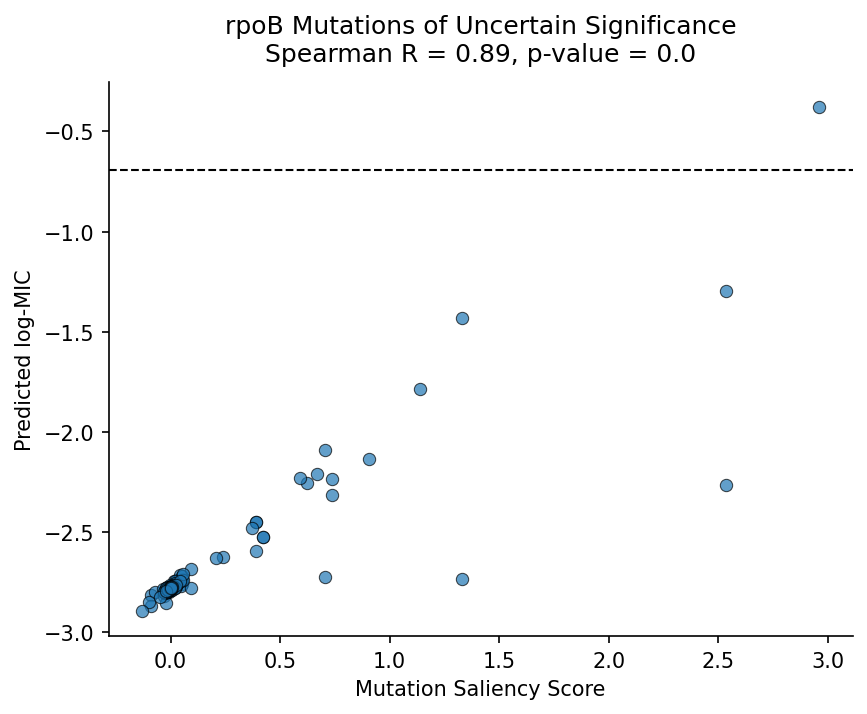

In [199]:
x = plot_df["saliency_score"].values
y = plot_df["MIC_pred"].values

plt.scatter(x, y, s=35, edgecolors="black", linewidths=0.5, alpha=0.7)
#fig, ax = plt.subplots()
# ax.scatter_density(x, y, cmap=white_viridis)
#plt.plot([np.min(plot_df["saliency_score"]), np.max(plot_df["saliency_score"])], [y0, y1], color="tomato")

corr, permuted_corrs, pval = perform_correlation_permutation_test(x, y, st.spearmanr)

plt.title(f"rpoB Mutations of Uncertain Significance\nSpearman R = {np.round(corr, 2)}, p-value = {pval}")
plt.axhline(y=np.log(0.5), color="black", linestyle="dashed", linewidth=1)
plt.xlabel("Mutation Saliency Score")
plt.ylabel("Predicted log-MIC")
sns.despine()
plt.savefig("/home/sak0914/uncertain_rpoB_scatter.png", dpi=300)

In [43]:
# nbins = 300
# k = st.kde.gaussian_kde([x,y])
# xi, yi = np.mgrid[x.min():x.max():nbins*1j, y.min():y.max():nbins*1j]
# zi = k(np.vstack([xi.flatten(), yi.flatten()]))
# plt.pcolormesh(xi, yi, zi.reshape(xi.shape), shading='auto', cmap="viridis")

In [61]:
# linReg = LinearRegression(fit_intercept=True)
# linReg.fit(x.reshape(-1, 1), y)

# y0 = linReg.intercept_ + np.min(plot_df["saliency_score"])*linReg.coef_[0]
# y1 = linReg.intercept_ + np.max(plot_df["saliency_score"])*linReg.coef_[0]